# 03 - Exploratory Analysis

Visualize the 2020-2024 county-level partisan swing and its relationship to demographics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

df = pd.read_csv('../data/processed/county_swing_dataset.csv', dtype={'FIPS': str, 'state_fips': str})

# drop Alaska for main analysis (different reporting geography)
df_main = df[~df['is_alaska']].copy()
print(f"Counties in analysis: {len(df_main)} (excluded {df['is_alaska'].sum()} Alaska boroughs)")

Counties in analysis: 3111 (excluded 41 Alaska boroughs)


## Swing distribution

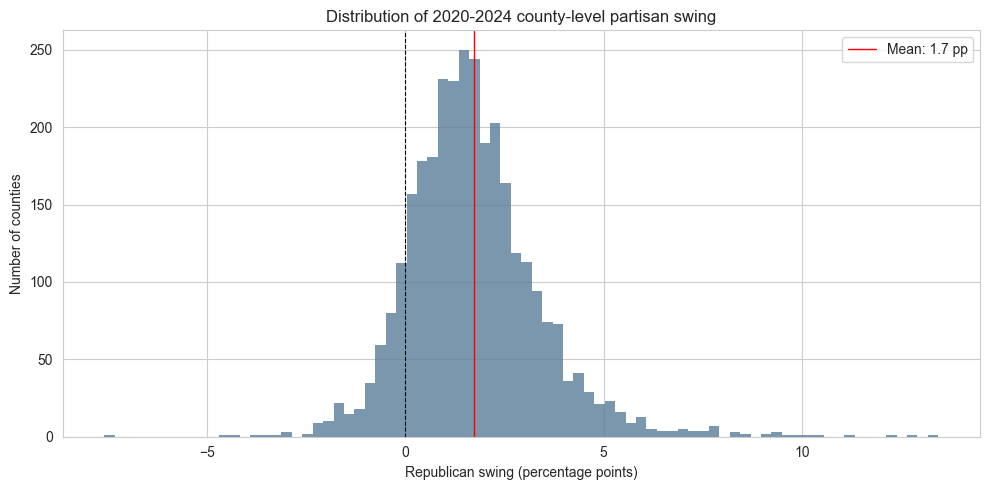

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_main['swing'] * 100, bins=80, edgecolor='none', alpha=0.8, color='#5a7d9a')
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)

mean_swing = df_main['swing'].mean() * 100
ax.axvline(mean_swing, color='red', linestyle='-', linewidth=1, label=f'Mean: {mean_swing:.1f} pp')

ax.set_xlabel('Republican swing (percentage points)')
ax.set_ylabel('Number of counties')
ax.set_title('Distribution of 2020-2024 county-level partisan swing')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/swing_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## County swing map

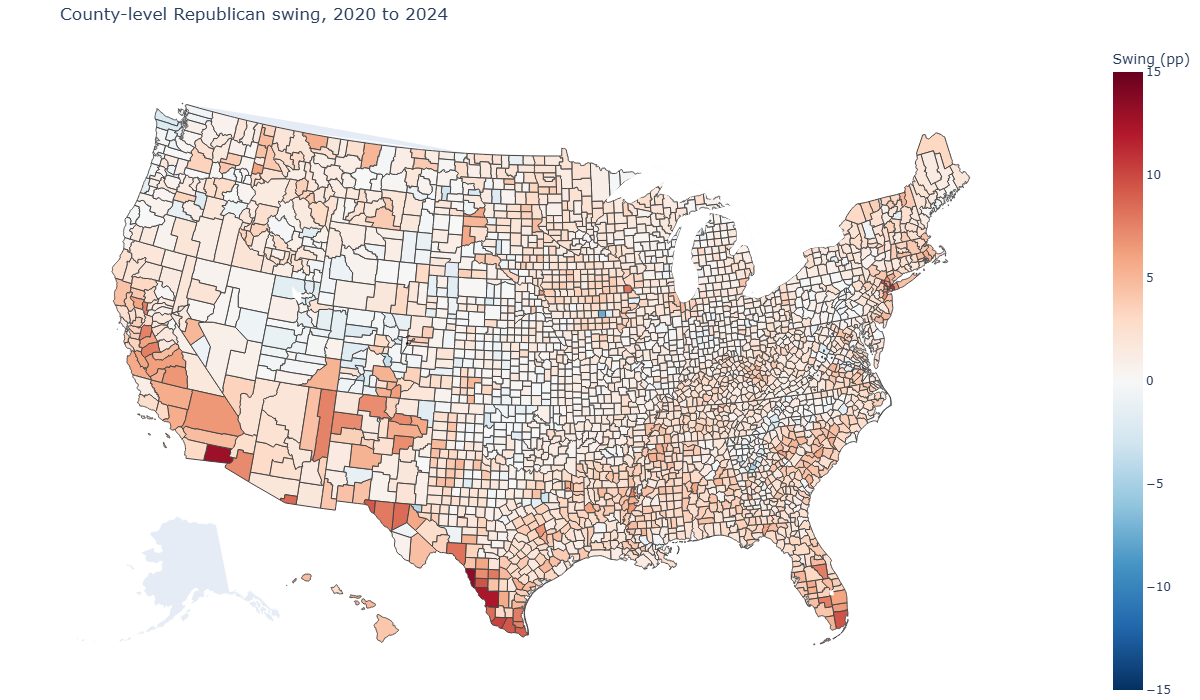

In [3]:
import plotly.express as px
from IPython.display import Image

map_df = df_main.dropna(subset=['swing']).copy()
map_df['swing_pp'] = map_df['swing'] * 100

fig = px.choropleth(
    map_df,
    geojson='https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json',
    locations='FIPS', color='swing_pp',
    color_continuous_scale='RdBu_r', color_continuous_midpoint=0,
    range_color=[-15, 15],
    scope='usa',
    labels={'swing_pp': 'Swing (pp)'},
    title='County-level Republican swing, 2020 to 2024',
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig.write_image('../figures/swing_choropleth.png', width=1200, height=700)
Image(filename='../figures/swing_choropleth.png')

## Swing by urban-rural classification

C:\Users\kaleb\AppData\Local\Temp\ipykernel_80956\2936211816.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='urban_rural_label', y=df_plot['swing'] * 100,


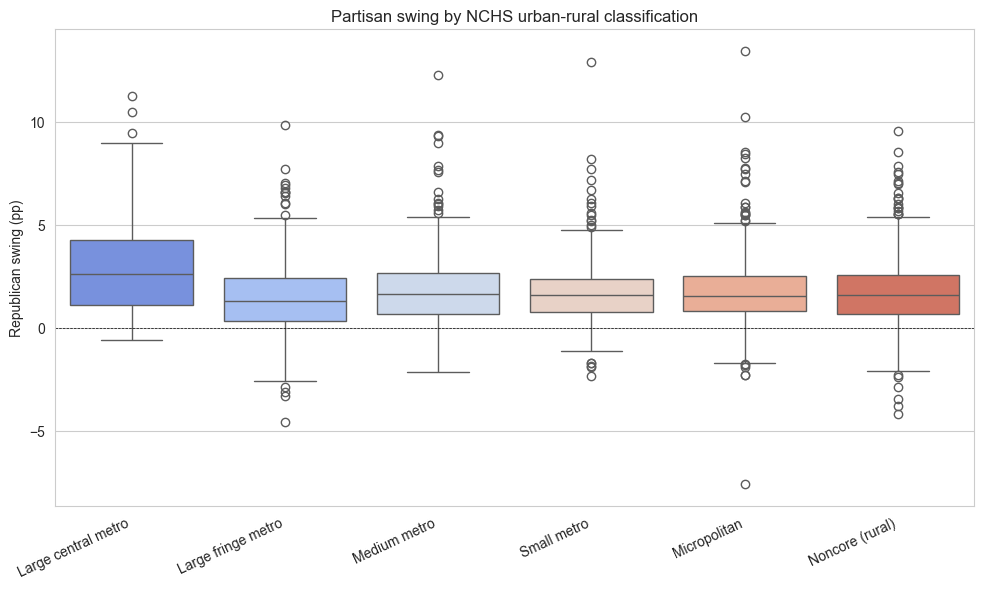

In [4]:
order = ['Large central metro', 'Large fringe metro', 'Medium metro',
         'Small metro', 'Micropolitan', 'Noncore (rural)']

fig, ax = plt.subplots(figsize=(10, 6))
df_plot = df_main.dropna(subset=['urban_rural_label'])
sns.boxplot(data=df_plot, x='urban_rural_label', y=df_plot['swing'] * 100,
            order=order, ax=ax, palette='coolwarm')
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_xlabel('')
ax.set_ylabel('Republican swing (pp)')
ax.set_title('Partisan swing by NCHS urban-rural classification')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('../figures/swing_by_urbanrural.png', dpi=150, bbox_inches='tight')
plt.show()

Large central metros show the highest median swing, which may seem counterintuitive. This is driven by high-Hispanic counties in states like Florida and Texas. After controlling for Hispanic share in the multilevel model (notebook 04), the urban-rural coefficients reverse direction.

## Education vs. swing

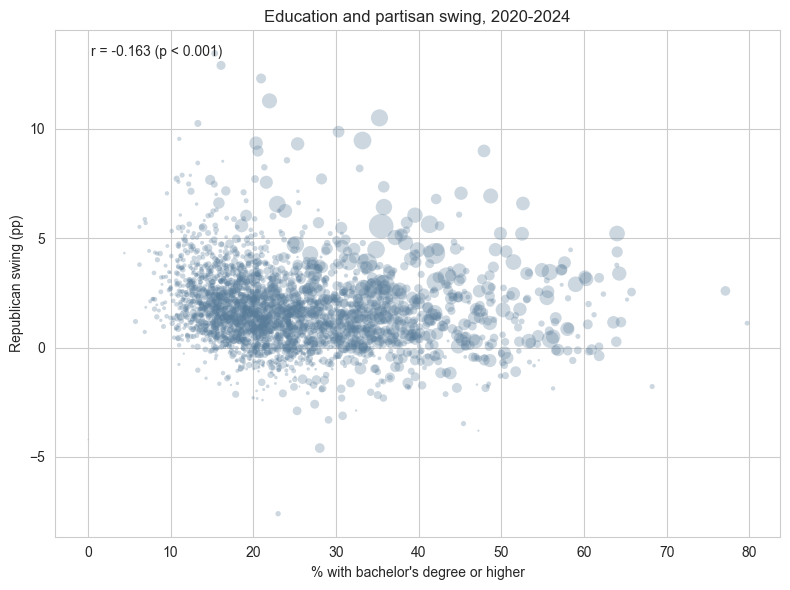

In [5]:
plot_df = df_main.dropna(subset=['pct_college', 'swing'])

fig, ax = plt.subplots(figsize=(8, 6))
sizes = np.sqrt(plot_df['total_pop'].fillna(1000)) / 10
ax.scatter(plot_df['pct_college'] * 100, plot_df['swing'] * 100,
           s=sizes, alpha=0.3, edgecolors='none', color='#5a7d9a')

ax.set_xlabel("% with bachelor's degree or higher")
ax.set_ylabel('Republican swing (pp)')
ax.set_title('Education and partisan swing, 2020-2024')

r, p = stats.pearsonr(plot_df['pct_college'], plot_df['swing'])
ax.annotate(f'r = {r:.3f} (p < 0.001)' if p < 0.001 else f'r = {r:.3f} (p = {p:.3f})',
            xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10)

plt.tight_layout()
plt.savefig('../figures/education_vs_swing.png', dpi=150, bbox_inches='tight')
plt.show()

## Hispanic share vs. swing

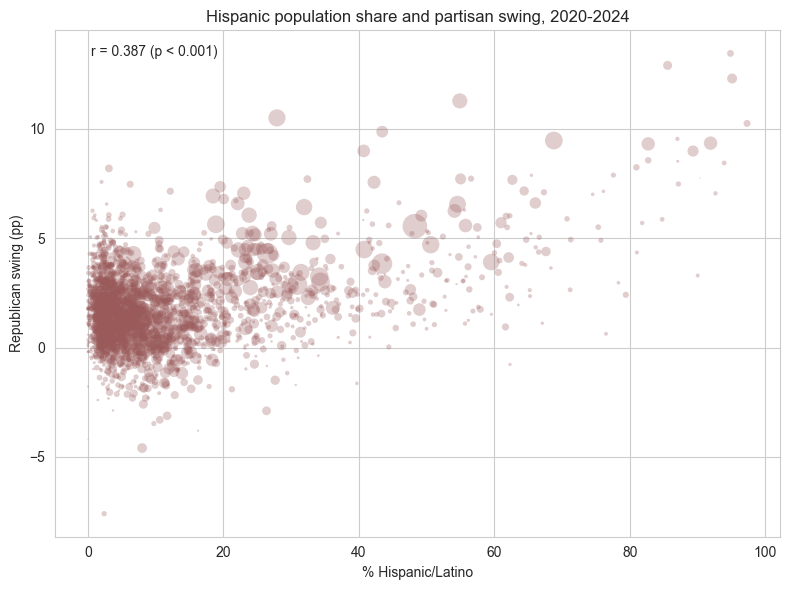

In [6]:
plot_df = df_main.dropna(subset=['pct_hispanic', 'swing'])

fig, ax = plt.subplots(figsize=(8, 6))
sizes = np.sqrt(plot_df['total_pop'].fillna(1000)) / 10
ax.scatter(plot_df['pct_hispanic'] * 100, plot_df['swing'] * 100,
           s=sizes, alpha=0.3, edgecolors='none', color='#9a5a5a')

ax.set_xlabel('% Hispanic/Latino')
ax.set_ylabel('Republican swing (pp)')
ax.set_title('Hispanic population share and partisan swing, 2020-2024')

r, p = stats.pearsonr(plot_df['pct_hispanic'], plot_df['swing'])
ax.annotate(f'r = {r:.3f} (p < 0.001)' if p < 0.001 else f'r = {r:.3f} (p = {p:.3f})',
            xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10)

plt.tight_layout()
plt.savefig('../figures/hispanic_vs_swing.png', dpi=150, bbox_inches='tight')
plt.show()

## Unemployment vs. swing

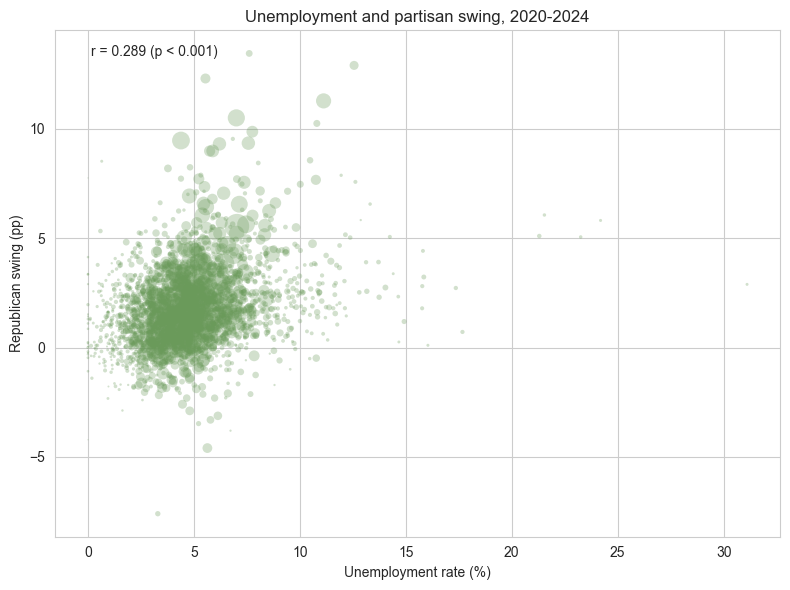

In [7]:
plot_df = df_main.dropna(subset=['pct_unemployed', 'swing'])

fig, ax = plt.subplots(figsize=(8, 6))
sizes = np.sqrt(plot_df['total_pop'].fillna(1000)) / 10
ax.scatter(plot_df['pct_unemployed'] * 100, plot_df['swing'] * 100,
           s=sizes, alpha=0.3, edgecolors='none', color='#6a9a5a')

ax.set_xlabel('Unemployment rate (%)')
ax.set_ylabel('Republican swing (pp)')
ax.set_title('Unemployment and partisan swing, 2020-2024')

r, p = stats.pearsonr(plot_df['pct_unemployed'], plot_df['swing'])
ax.annotate(f'r = {r:.3f} (p < 0.001)' if p < 0.001 else f'r = {r:.3f} (p = {p:.3f})',
            xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10)

plt.tight_layout()
plt.savefig('../figures/unemployment_vs_swing.png', dpi=150, bbox_inches='tight')
plt.show()

## Population density vs. swing

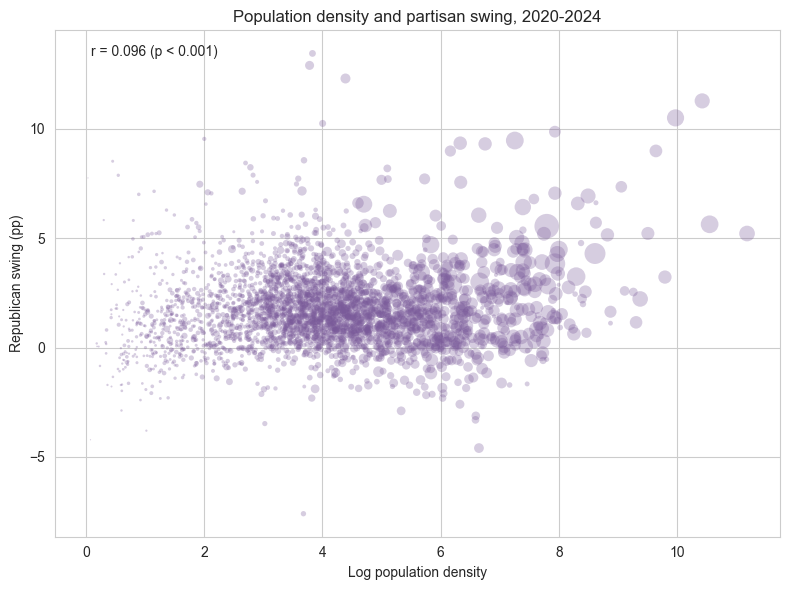

In [8]:
plot_df = df_main.dropna(subset=['log_pop_density', 'swing'])

fig, ax = plt.subplots(figsize=(8, 6))
sizes = np.sqrt(plot_df['total_pop'].fillna(1000)) / 10
ax.scatter(plot_df['log_pop_density'], plot_df['swing'] * 100,
           s=sizes, alpha=0.3, edgecolors='none', color='#7a5a9a')

ax.set_xlabel('Log population density')
ax.set_ylabel('Republican swing (pp)')
ax.set_title('Population density and partisan swing, 2020-2024')

r, p = stats.pearsonr(plot_df['log_pop_density'], plot_df['swing'])
ax.annotate(f'r = {r:.3f} (p < 0.001)' if p < 0.001 else f'r = {r:.3f} (p = {p:.3f})',
            xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10)

plt.tight_layout()
plt.savefig('../figures/popdensity_vs_swing.png', dpi=150, bbox_inches='tight')
plt.show()

## Correlation heatmap

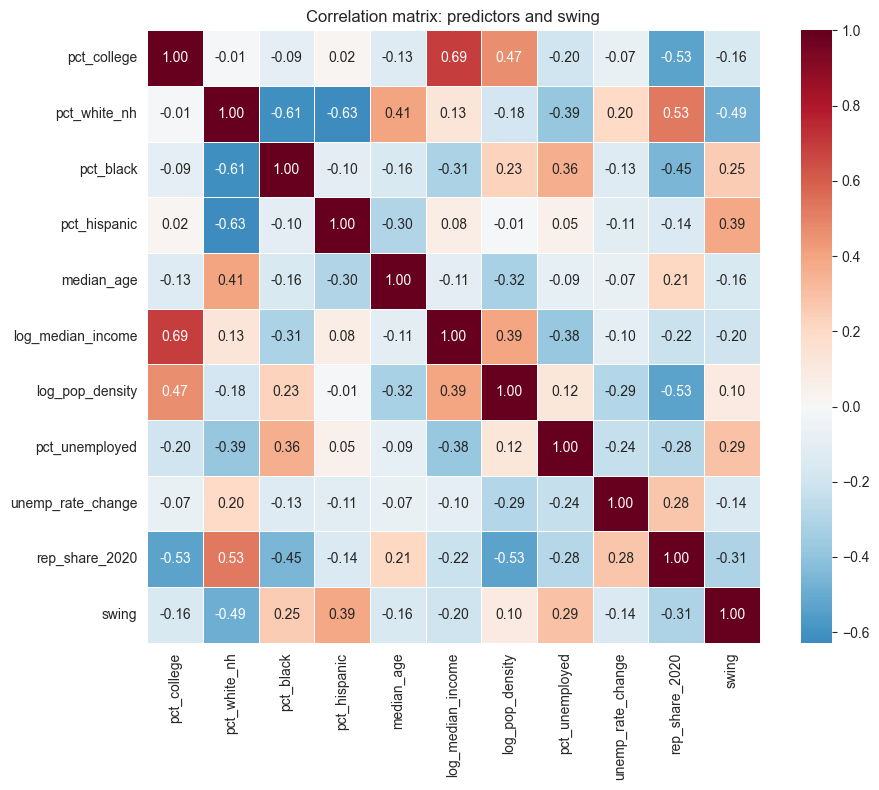

In [9]:
feature_cols = [
    'pct_college', 'pct_white_nh', 'pct_black', 'pct_hispanic',
    'median_age', 'log_median_income', 'log_pop_density',
    'pct_unemployed', 'unemp_rate_change', 'rep_share_2020',
]

corr_df = df_main.rename(columns={'rep_share_2020': 'rep_share_2020'})
corr = corr_df[feature_cols + ['swing']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation matrix: predictors and swing')
plt.tight_layout()
plt.savefig('../figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## OLS regression: swing predicted by demographics

A simple pooled OLS as a first pass before moving to multilevel models. Using heteroskedasticity-consistent (HC1) standard errors since county populations vary wildly.

In [10]:
features = [
    'pct_college', 'pct_hispanic', 'pct_black', 'pct_white_nh',
    'log_median_income', 'log_pop_density', 'median_age',
    'pct_unemployed', 'rep_share_2020',
]

model_df = df_main[features + ['swing']].dropna()
print(f"Observations in model: {len(model_df)}")

X = sm.add_constant(model_df[features])
y = model_df['swing']

ols = sm.OLS(y, X).fit(cov_type='HC1')
print(ols.summary())

Observations in model: 3101
                            OLS Regression Results                            
Dep. Variable:                  swing   R-squared:                       0.352
Model:                            OLS   Adj. R-squared:                  0.350
Method:                 Least Squares   F-statistic:                     89.87
Date:                Thu, 05 Mar 2026   Prob (F-statistic):          5.02e-149
Time:                        16:58:58   Log-Likelihood:                 8930.4
No. Observations:                3101   AIC:                        -1.784e+04
Df Residuals:                    3091   BIC:                        -1.778e+04
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const     

## Population-weighted swing by state

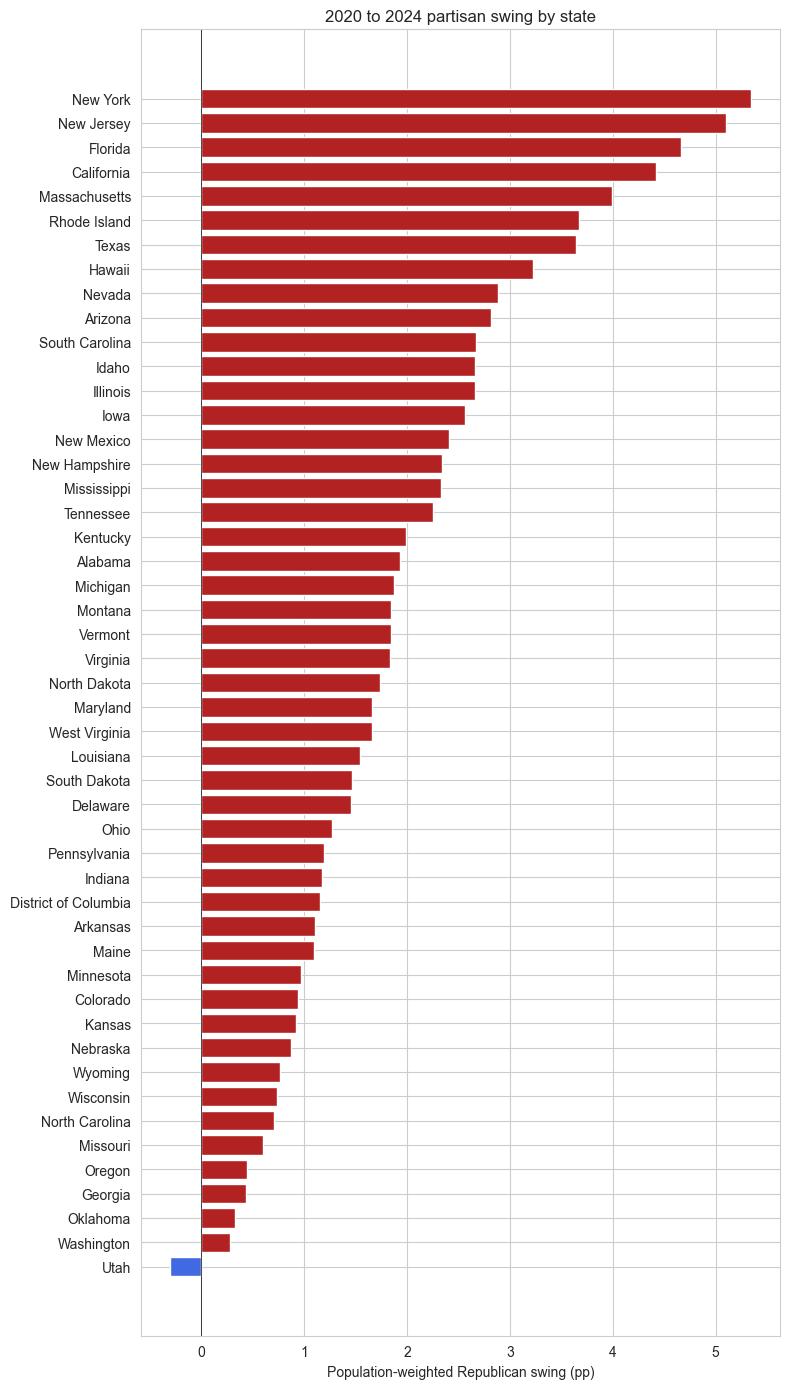

In [11]:
state_swing = (
    df_main
    .dropna(subset=['swing', 'total_pop'])
    .groupby('state_fips')
    .apply(lambda g: np.average(g['swing'], weights=g['total_pop']), include_groups=False)
    .reset_index(name='pop_weighted_swing')
    .sort_values('pop_weighted_swing')
)

# map state FIPS to names
try:
    from us import states
    fips_to_name = {s.fips: s.name for s in states.STATES_AND_TERRITORIES}
    fips_to_name["11"] = "District of Columbia"
    state_swing['state_name'] = state_swing['state_fips'].map(fips_to_name)
except ImportError:
    state_swing['state_name'] = state_swing['state_fips']

# fall back to FIPS code for any unmapped states
state_swing['state_name'] = state_swing['state_name'].fillna(state_swing['state_fips'])

fig, ax = plt.subplots(figsize=(8, 14))
colors = ['#b22222' if x > 0 else '#4169e1' for x in state_swing['pop_weighted_swing']]
ax.barh(state_swing['state_name'], state_swing['pop_weighted_swing'] * 100, color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Population-weighted Republican swing (pp)')
ax.set_title('2020 to 2024 partisan swing by state')
plt.tight_layout()
plt.savefig('../figures/state_swing_bar.png', dpi=150, bbox_inches='tight')
plt.show()